#### Case opti-4: Isobaric evaporation of ammonia in a large tank for long-term storage


In [1]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

#import optimization class
from cryoevap.optimize import Opti

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

#### Setup tank and cryogen properties

Overall heat transfer coefficient calculation from the wall exam

In [2]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
T_air = 5.3286+273.15 # Temperature of the environment K

V_tank = 88023.6952 # Tank volume / m^3

a    = 0.5  # aspect ratio H/D
d_i  = ((4 * V_tank)/(np.pi * a))**(1/3) # internal diameter / m
e    = 10.6972*2 - 10.24*2 # twice the wall thickness / m
d_o  = d_i + e   # External diameter / m

# Internal heat transfer coefficient
h_L = 135.079

# External heat transfer coefficient - forced convection
h_env = 13.745

# Wall heat transfer coefficient
k_w = 0.0411

# Equivalent diameter
d_eq = (d_o-d_i)/np.log(d_o/d_i)

# Overall heat transfer coefficient
#U = (d_o/d_i * 1/h_L +  1/h_env + d_o/d_eq * (e/2)/k_w)**(-1)
r_o = d_o/2
r_i = d_i/2
U = (r_o/r_i * 1/h_L +  1/h_env + (r_o) * np.log(r_o/r_i)/k_w)**(-1)

print("U = %.5e W m^-2 K^-1 " % U)
print("h_L = %.3f W m^-2 K^-1" % h_L)
print("h_env = %.3f W m^-2 K^-1" % h_env)
print("k_w = %.3e W m^-2 K^-1" % k_w)
print("Wall thickness e/2 = %.3e m" % (e/2))

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = U # Old hard coded value, 0.08 # W/m2/K
U_V = U # Old hard coded value, 0.08 # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.95 

# Specify tank operating pressure
P = 101325 # Pa

# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)
large_tank.set_HeatTransProps(U_L, U_V, T_air, q_b_fixed = None, Q_roof = 0, eta_w = 0.70)
large_tank.U_b = 0.08801 # Set bottom U value, 5 sf
# # Initialise cryogen
cryogen = Cryogen(name = "ammonia")
cryogen.set_coolprops(P)

# # Set cryogen
large_tank.cryogen = cryogen

# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

U = 8.85923e-02 W m^-2 K^-1 
h_L = 135.079 W m^-2 K^-1
h_env = 13.745 W m^-2 K^-1
k_w = 4.110e-02 W m^-2 K^-1
Wall thickness e/2 = 4.572e-01 m
The initial evaporation rate of ammonia is 78.1 kg/h


Calculate initial evaporation rate and transient period

In [3]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % large_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h = (np.floor(large_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h )

# Calculate boil-off rate
BOR = (large_tank.b_l_dot * 24 * 3600) / (large_tank.V * large_tank.LF * large_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR * 100))

The initial evaporation rate of ammonia is 78.1 kg/h
Transient period = 361306.499 s 
Simulation time: 101 h
BOR = 0.003 %


#### Simulation setup and execution

In [4]:
# Define vertical spacing
dz = 0.05

# Calculate number of nodes
n_z = 1 + int(np.round(large_tank.l_V/dz, 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 720 hours
evap_time = 3600 * 24 * 7 * 3

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 3600

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6

# Simulate the evaporation
large_tank.evaporate(evap_time)

In [5]:
# Save large_tank.data using pkl
import pickle
with open('large_tank_data_LF95_3weeks_wo_wall.pkl', 'wb') as f:
    pickle.dump(large_tank.data, f)

#### Visualisation of results

#### Vapour temperature

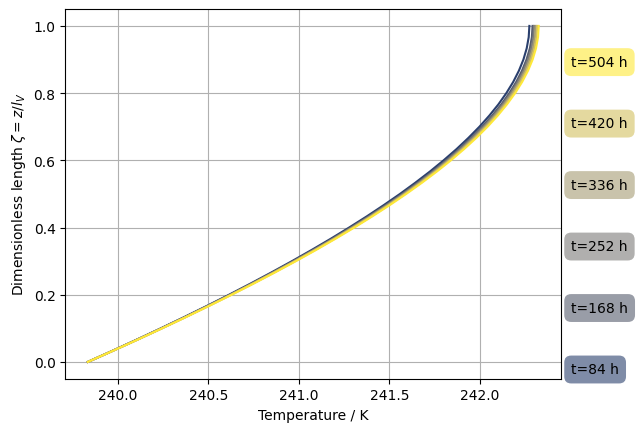

In [6]:
# Visualise the plot
large_tank.plot_tv(t_unit='h')

Visualise liquid and vapour heat ingresses, $\dot{Q}_{\text{L}}$ and  $\dot{Q}_{\text{V}}$.

The plot also shows the vapour to liquid heat ingress, $\dot{Q}_{VL}$, and  the partition of the vapour heat ingress that is transferred to the interface by the wall directly, $\dot{Q}_{\text{V,w}}$

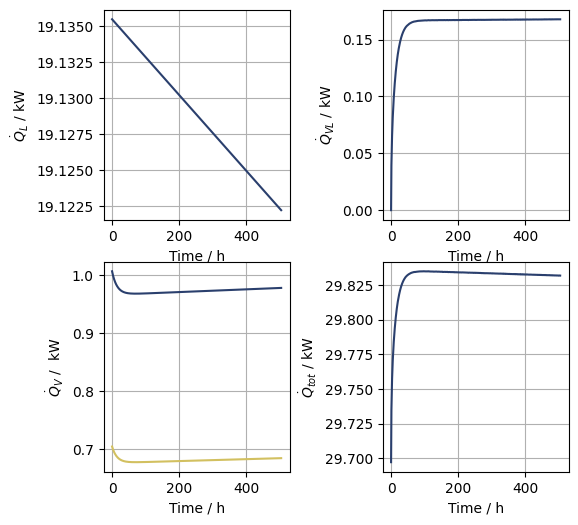

In [7]:
large_tank.plot_Q(unit='kW', t_unit='h')

#### Plot liquid volume

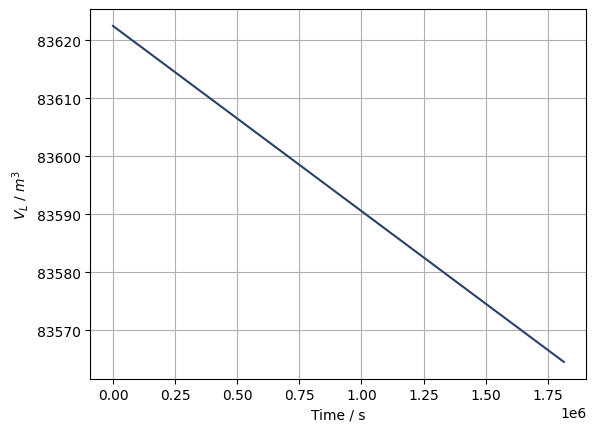

In [8]:
large_tank.plot_V_L()

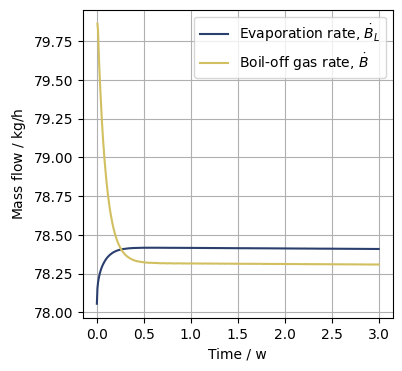

In [9]:
large_tank.plot_BOG(unit='kg/h', t_unit='w')

Optional: CSV data export

If evaporation data is intended to be post-processed in another software, it can be exported readily with the help of the Pandas package.

In [10]:
# Import pandas 
import pandas as pd

In [11]:
# Create dataframe from dictionary
df_evap = pd.DataFrame.from_dict(large_tank.data)

# Save file to the current working directory
df_evap.to_csv('methane_165000m3.csv')

# Show the first five columns of the dataframe in console
df_evap.head()

,Time,Tv_avg,rho_V_avg,Q_VL,Q_L,Q_V,V_L,B_L,BOG,drho_V_avg,dV_L,T_BOG,Q_Vw,Q_tot
0,0,239.834319,0.889926,-1.711933e-11,19135.500460,1007.131603,83622.510440,0.021682,0.021682,0.000000e+00,0.000000,239.834319,704.992122,29697.239634
1,3600,239.943013,0.889514,3.938758e+01,19135.474234,1004.324996,83622.395830,0.021709,0.022184,-1.143099e-07,-0.000032,239.955355,703.027497,29734.636363
2,7200,240.040640,0.889103,5.455699e+01,19135.447991,1001.806728,83622.281146,0.021719,0.022174,-1.096706e-07,-0.000032,240.076098,701.264709,29748.016745
3,10800,240.130458,0.888724,6.539116e+01,19135.421737,999.491858,83622.166419,0.021726,0.022143,-1.011431e-07,-0.000032,240.196297,699.644300,29757.204254
4,14400,240.213728,0.888374,7.410427e+01,19135.395477,997.347532,83622.051661,0.021731,0.022116,-9.380324e-08,-0.000032,240.315058,698.143273,29764.390067


In [12]:
# BOR = (1 - large_tank.data['V_L'][-1]/large_tank.data['V_L'][0])* (86400/large_tank.data['Time'][-1])
BOR = large_tank.BOR()
print("BOR = %.3e %%" % (100 * BOR))

BOR = 3.301e-03 %


In [13]:
large_tank.BOR()

np.float64(3.301358028736815e-05)

In [14]:
large_tank.data['Time'][-1]

np.int64(1814400)

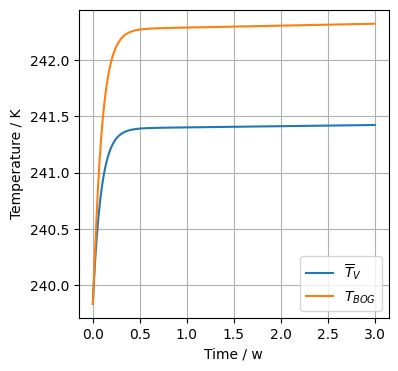

In [15]:
large_tank.plot_tv_BOG(t_unit='w')

#### References



F. Huerta, V. Vesovic, A realistic vapour phase heat transfer model for the weathering of LNG stored in large tanks, Energy, 174 (2019) 280-291.